In [1]:
# ========================================
# TOXIC LANGUAGE DETECTION - COMPLETE PIPELINE
# CS 584 Final Project - Final Report Implementation
# Christopher Kang and Koen Mitchel Santos
# ========================================

# %% [markdown]
# # 1. Setup and Imports

# %%


import os, json, re, pickle, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.calibration import CalibratedClassifierCV
from itertools import product
import warnings
warnings.filterwarnings('ignore')


In [2]:
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        get_linear_schedule_with_warmup
    )
    from datasets import Dataset as HFDataset, DatasetDict
    TRANSFORMERS_AVAILABLE = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
except Exception as e:
    print(f"Transformers not available: {e}")
    TRANSFORMERS_AVAILABLE = False


Using device: cpu


In [3]:
# Constants
RANDOM_STATE = 42
JIGSAW_PATH = 'jigsaw_train.csv'
TWITTER_PATH = 'twitter_hate_speech.csv'
OUTPUT_DIR = 'final_report_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set random seeds
np.random.seed(RANDOM_STATE)
if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

print("=" * 80)
print("SETUP COMPLETE")
print("=" * 80)


SETUP COMPLETE


In [4]:

print("\n" + "=" * 80)
print("LOADING DATASETS")
print("=" * 80)

# Load datasets
df_jigsaw = pd.read_csv(JIGSAW_PATH)
df_twitter = pd.read_csv(TWITTER_PATH)

print(f"\nJigsaw Dataset:")
print(f"  Shape: {df_jigsaw.shape}")
print(f"  Columns: {df_jigsaw.columns.tolist()}")
print(f"\nTwitter Dataset:")
print(f"  Shape: {df_twitter.shape}")
print(f"  Columns: {df_twitter.columns.tolist()}")

# Display sample data
print(f"\nJigsaw Sample:")
print(df_jigsaw.head())
print(f"\nTwitter Sample:")
print(df_twitter.head())


LOADING DATASETS

Jigsaw Dataset:
  Shape: (159571, 8)
  Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Twitter Dataset:
  Shape: (24783, 7)
  Columns: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Jigsaw Sample:
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0      

In [5]:
# Analyze Jigsaw label distribution
print("\n" + "=" * 80)
print("JIGSAW LABEL DISTRIBUTION")
print("=" * 80)

jigsaw_label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
for col in jigsaw_label_cols:
    if col in df_jigsaw.columns:
        count = df_jigsaw[col].sum()
        pct = (count / len(df_jigsaw)) * 100
        print(f"  {col:15s}: {count:6d} ({pct:5.2f}%)")

# Analyze Twitter class distribution
print("\n" + "=" * 80)
print("TWITTER CLASS DISTRIBUTION")
print("=" * 80)
if 'class' in df_twitter.columns:
    print(df_twitter['class'].value_counts().sort_index())
    print("\nClass mapping:")
    print("  0: hate_speech")
    print("  1: offensive_language")
    print("  2: neither")



JIGSAW LABEL DISTRIBUTION
  toxic          :  15294 ( 9.58%)
  severe_toxic   :   1595 ( 1.00%)
  obscene        :   8449 ( 5.29%)
  threat         :    478 ( 0.30%)
  insult         :   7877 ( 4.94%)
  identity_hate  :   1405 ( 0.88%)

TWITTER CLASS DISTRIBUTION
class
0     1430
1    19190
2     4163
Name: count, dtype: int64

Class mapping:
  0: hate_speech
  1: offensive_language
  2: neither


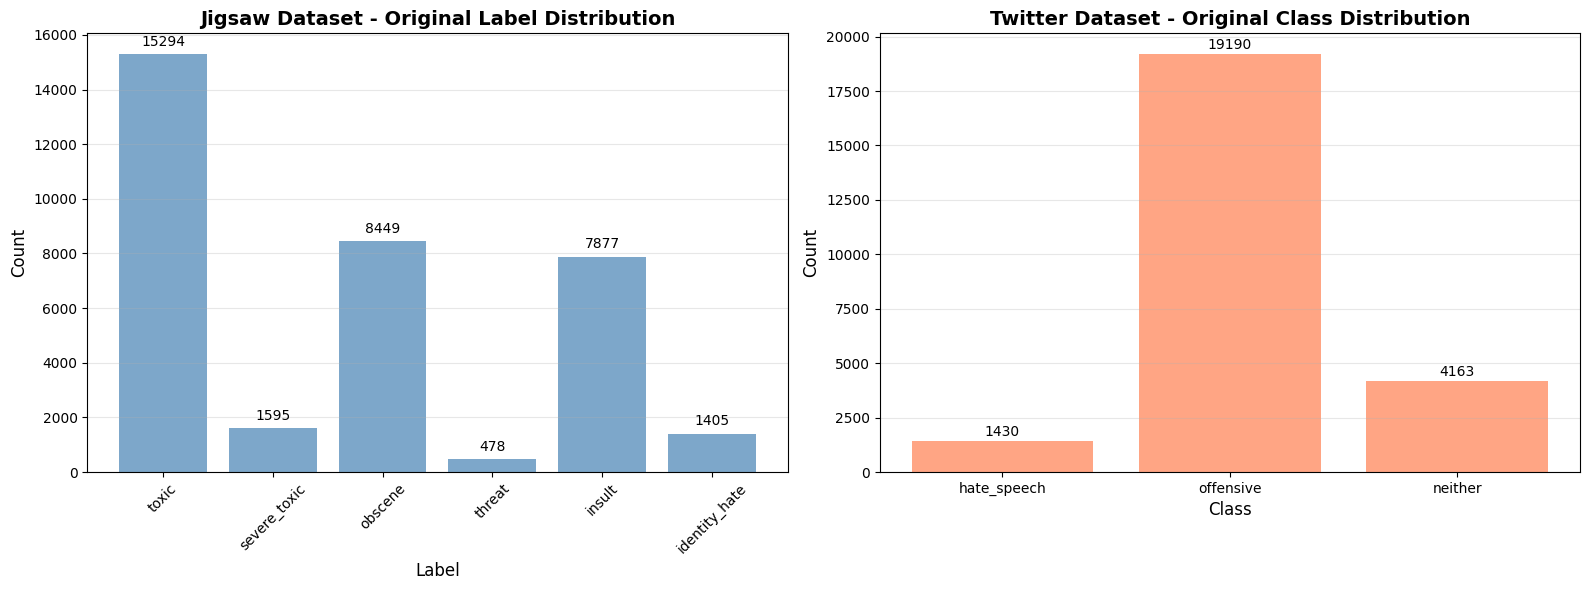


Saved: final_report_outputs/original_label_distribution.png


In [6]:
# Visualize original label distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Jigsaw labels
jigsaw_counts = [df_jigsaw[col].sum() for col in jigsaw_label_cols if col in df_jigsaw.columns]
jigsaw_labels = [col for col in jigsaw_label_cols if col in df_jigsaw.columns]
axes[0].bar(jigsaw_labels, jigsaw_counts, color='steelblue', alpha=0.7)
axes[0].set_title('Jigsaw Dataset - Original Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(jigsaw_counts):
    axes[0].text(i, v + 200, str(v), ha='center', va='bottom', fontsize=10)

# Twitter classes
if 'class' in df_twitter.columns:
    twitter_class_counts = df_twitter['class'].value_counts().sort_index()
    axes[1].bar(['hate_speech', 'offensive', 'neither'], twitter_class_counts.values,
                color='coral', alpha=0.7)
    axes[1].set_title('Twitter Dataset - Original Class Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Class', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(twitter_class_counts.values):
        axes[1].text(i, v + 100, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'original_label_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'original_label_distribution.png')}")



In [7]:
# %%
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

def preprocess_text(text):
    """
    Clean and normalize text data:
    - Lowercase
    - Remove URLs
    - Remove mentions and hashtags
    - Remove special characters
    - Normalize whitespace
    """
    if not isinstance(text, str):
        return ''

    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # Remove URLs
    text = re.sub(r'@\w+', ' ', text)               # Remove mentions
    text = re.sub(r'#', '', text)                   # Remove hashtag symbol
    text = re.sub(r"[^\w\s'\-]", ' ', text)         # Keep only words, spaces, apostrophes, hyphens
    text = re.sub(r'\s+', ' ', text).strip()        # Normalize whitespace

    return text

# Apply preprocessing
print("Preprocessing Jigsaw dataset...")
df_jigsaw['text_clean'] = df_jigsaw['comment_text'].apply(preprocess_text)

print("Preprocessing Twitter dataset...")
df_twitter['text_clean'] = df_twitter['tweet'].apply(preprocess_text)

# Remove empty entries
df_jigsaw = df_jigsaw[df_jigsaw['text_clean'] != ''].reset_index(drop=True)
df_twitter = df_twitter[df_twitter['text_clean'] != ''].reset_index(drop=True)

print(f"\nAfter preprocessing:")
print(f"  Jigsaw: {df_jigsaw.shape}")
print(f"  Twitter: {df_twitter.shape}")

# Display examples
print("\nExample cleaned texts:")
for i in range(3):
    print(f"\n  Original: {df_jigsaw.iloc[i]['comment_text'][:100]}...")
    print(f"  Cleaned:  {df_jigsaw.iloc[i]['text_clean'][:100]}...")




DATA PREPROCESSING
Preprocessing Jigsaw dataset...
Preprocessing Twitter dataset...

After preprocessing:
  Jigsaw: (159558, 9)
  Twitter: (24783, 8)

Example cleaned texts:

  Original: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't ...
  Cleaned:  explanation why the edits made under my username hardcore metallica fan were reverted they weren't v...

  Original: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11...
  Cleaned:  d'aww he matches this background colour i'm seemingly stuck with thanks talk 21 51 january 11 2016 u...

  Original: Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant ...
  Cleaned:  hey man i'm really not trying to edit war it's just that this guy is constantly removing relevant in...


In [8]:
print("\n" + "=" * 80)
print("LABEL HARMONIZATION TO 7-CLASS SYSTEM")
print("=" * 80)

# Create unified label system
# Classes: toxic, severe_toxic, obscene, threat, insult, identity_hate, none

def jigsaw_row_to_label(row):
    """
    Map Jigsaw multi-label to single unified label.
    Priority: severe_toxic > threat > identity_hate > toxic > obscene > insult > none
    """
    if int(row.get('severe_toxic', 0)) == 1:
        return 'severe_toxic'
    if int(row.get('threat', 0)) == 1:
        return 'threat'
    if int(row.get('identity_hate', 0)) == 1:
        return 'identity_hate'
    if int(row.get('toxic', 0)) == 1:
        return 'toxic'
    if int(row.get('obscene', 0)) == 1:
        return 'obscene'
    if int(row.get('insult', 0)) == 1:
        return 'insult'
    return 'none'

def twitter_class_to_label(class_val):
    """
    Map Twitter class to unified label.
    0: hate_speech -> identity_hate
    1: offensive_language -> insult
    2: neither -> none
    """
    try:
        class_val = int(class_val)
    except:
        return 'none'

    if class_val == 0:
        return 'identity_hate'
    elif class_val == 1:
        return 'insult'
    else:
        return 'none'

# Apply label mapping
print("Creating unified labels for Jigsaw...")
df_jigsaw['label'] = df_jigsaw.apply(jigsaw_row_to_label, axis=1)

print("Creating unified labels for Twitter...")
if 'class' in df_twitter.columns:
    df_twitter['label'] = df_twitter['class'].map(twitter_class_to_label)
else:
    df_twitter['label'] = 'none'

# Extract text and label columns
df_jigsaw_clean = df_jigsaw[['text_clean', 'label']].copy()
df_jigsaw_clean['source'] = 'jigsaw'

df_twitter_clean = df_twitter[['text_clean', 'label']].copy()
df_twitter_clean['source'] = 'twitter'

print("\nJigsaw label distribution:")
print(df_jigsaw_clean['label'].value_counts())

print("\nTwitter label distribution:")
print(df_twitter_clean['label'].value_counts())


LABEL HARMONIZATION TO 7-CLASS SYSTEM
Creating unified labels for Jigsaw...
Creating unified labels for Twitter...

Jigsaw label distribution:
label
none             143333
toxic             12439
severe_toxic       1595
identity_hate      1026
obscene             498
threat              366
insult              301
Name: count, dtype: int64

Twitter label distribution:
label
insult           19190
none              4163
identity_hate     1430
Name: count, dtype: int64


In [9]:
# Create label mapping
all_labels = sorted(['none', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'])
label2id = {label: idx for idx, label in enumerate(all_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("\n" + "=" * 80)
print("LABEL MAPPING")
print("=" * 80)
for label, idx in label2id.items():
    print(f"  {idx}: {label}")

# Add numeric label IDs
df_jigsaw_clean['label_id'] = df_jigsaw_clean['label'].map(label2id)
df_twitter_clean['label_id'] = df_twitter_clean['label'].map(label2id)


LABEL MAPPING
  0: identity_hate
  1: insult
  2: none
  3: obscene
  4: severe_toxic
  5: threat
  6: toxic


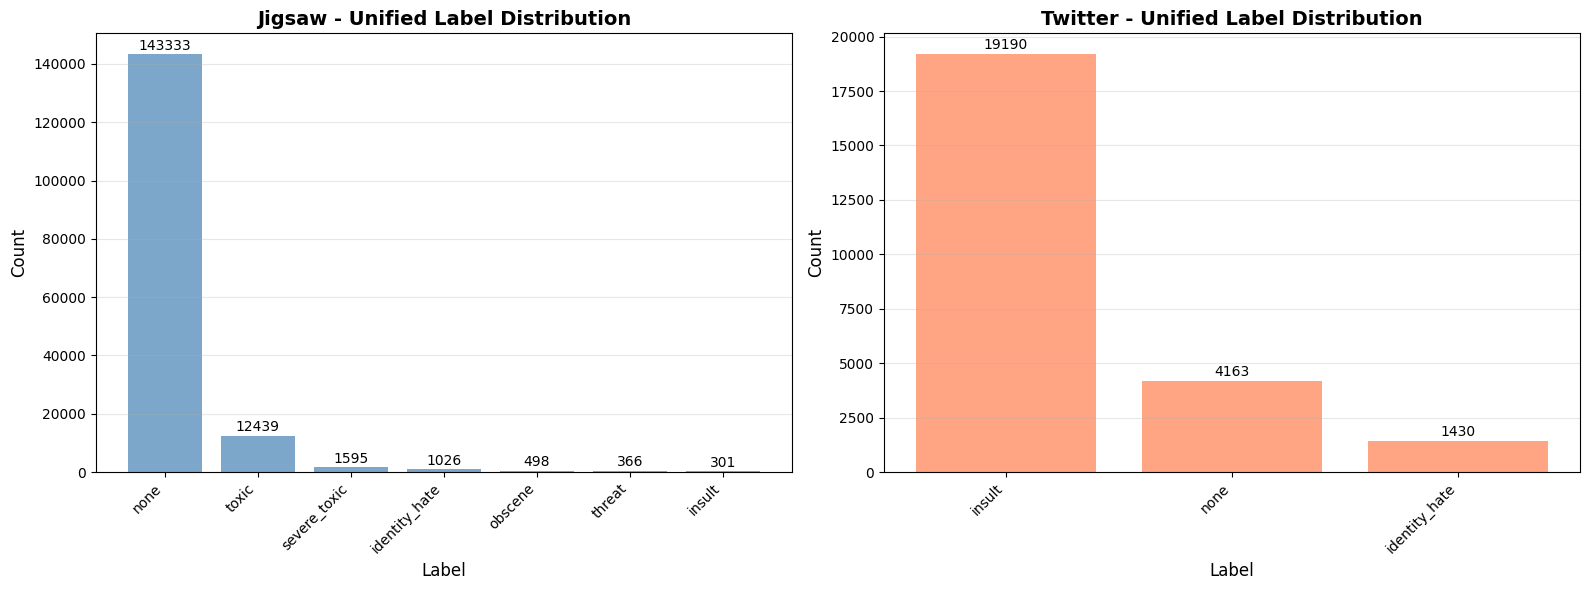


Saved: final_report_outputs/unified_label_distribution.png


In [10]:
# Visualize unified label distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Jigsaw unified labels
jigsaw_label_counts = df_jigsaw_clean['label'].value_counts()
axes[0].bar(range(len(jigsaw_label_counts)), jigsaw_label_counts.values,
            color='steelblue', alpha=0.7)
axes[0].set_xticks(range(len(jigsaw_label_counts)))
axes[0].set_xticklabels(jigsaw_label_counts.index, rotation=45, ha='right')
axes[0].set_title('Jigsaw - Unified Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(jigsaw_label_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', va='bottom', fontsize=10)

# Twitter unified labels
twitter_label_counts = df_twitter_clean['label'].value_counts()
axes[1].bar(range(len(twitter_label_counts)), twitter_label_counts.values,
            color='coral', alpha=0.7)
axes[1].set_xticks(range(len(twitter_label_counts)))
axes[1].set_xticklabels(twitter_label_counts.index, rotation=45, ha='right')
axes[1].set_title('Twitter - Unified Label Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(twitter_label_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'unified_label_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'unified_label_distribution.png')}")

In [11]:
print("\n" + "=" * 80)
print("COMBINING DATASETS")
print("=" * 80)

# Combine both datasets
df_combined = pd.concat([df_jigsaw_clean, df_twitter_clean], ignore_index=True)
df_combined = df_combined.dropna(subset=['text_clean', 'label']).reset_index(drop=True)

print(f"Combined dataset shape: {df_combined.shape}")
print(f"\nCombined label distribution:")
print(df_combined['label'].value_counts().sort_index())
print(f"\nSource distribution:")
print(df_combined['source'].value_counts())

# Basic statistics
print(f"\nBasic Statistics:")
print(f"  Total samples: {len(df_combined):,}")
print(f"  Unique labels: {df_combined['label'].nunique()}")
print(f"  From Jigsaw: {len(df_jigsaw_clean):,} ({len(df_jigsaw_clean)/len(df_combined)*100:.1f}%)")
print(f"  From Twitter: {len(df_twitter_clean):,} ({len(df_twitter_clean)/len(df_combined)*100:.1f}%)")

# Text length statistics
df_combined['text_length'] = df_combined['text_clean'].str.len()
df_combined['word_count'] = df_combined['text_clean'].str.split().str.len()

print(f"\nText Length Statistics:")
print(f"  Mean length: {df_combined['text_length'].mean():.1f} characters")
print(f"  Median length: {df_combined['text_length'].median():.1f} characters")
print(f"  Mean words: {df_combined['word_count'].mean():.1f}")
print(f"  Median words: {df_combined['word_count'].median():.1f}")


COMBINING DATASETS
Combined dataset shape: (184341, 4)

Combined label distribution:
label
identity_hate      2456
insult            19491
none             147496
obscene             498
severe_toxic       1595
threat              366
toxic             12439
Name: count, dtype: int64

Source distribution:
source
jigsaw     159558
twitter     24783
Name: count, dtype: int64

Basic Statistics:
  Total samples: 184,341
  Unique labels: 7
  From Jigsaw: 159,558 (86.6%)
  From Twitter: 24,783 (13.4%)

Text Length Statistics:
  Mean length: 333.2 characters
  Median length: 155.0 characters
  Mean words: 60.1
  Median words: 29.0


In [12]:
print("\n" + "=" * 80)
print("CREATING STRATIFIED TRAIN/DEV/TEST SPLITS (80/10/10)")
print("=" * 80)

# Stratified split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df_combined,
    test_size=0.2,
    stratify=df_combined['label'],
    random_state=RANDOM_STATE
)

# Split temp into 50% dev, 50% test (10% each of total)
dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=RANDOM_STATE
)

print(f"Split sizes:")
print(f"  Train: {len(train_df):,} ({len(train_df)/len(df_combined)*100:.1f}%)")
print(f"  Dev:   {len(dev_df):,} ({len(dev_df)/len(df_combined)*100:.1f}%)")
print(f"  Test:  {len(test_df):,} ({len(test_df)/len(df_combined)*100:.1f}%)")

# Verify stratification
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"\nDev label distribution:")
print(dev_df['label'].value_counts().sort_index())
print(f"\nTest label distribution:")
print(test_df['label'].value_counts().sort_index())


CREATING STRATIFIED TRAIN/DEV/TEST SPLITS (80/10/10)
Split sizes:
  Train: 147,472 (80.0%)
  Dev:   18,434 (10.0%)
  Test:  18,435 (10.0%)

Train label distribution:
label
identity_hate      1965
insult            15593
none             117996
obscene             398
severe_toxic       1276
threat              293
toxic              9951
Name: count, dtype: int64

Dev label distribution:
label
identity_hate      245
insult            1949
none             14750
obscene             50
severe_toxic       159
threat              37
toxic             1244
Name: count, dtype: int64

Test label distribution:
label
identity_hate      246
insult            1949
none             14750
obscene             50
severe_toxic       160
threat              36
toxic             1244
Name: count, dtype: int64


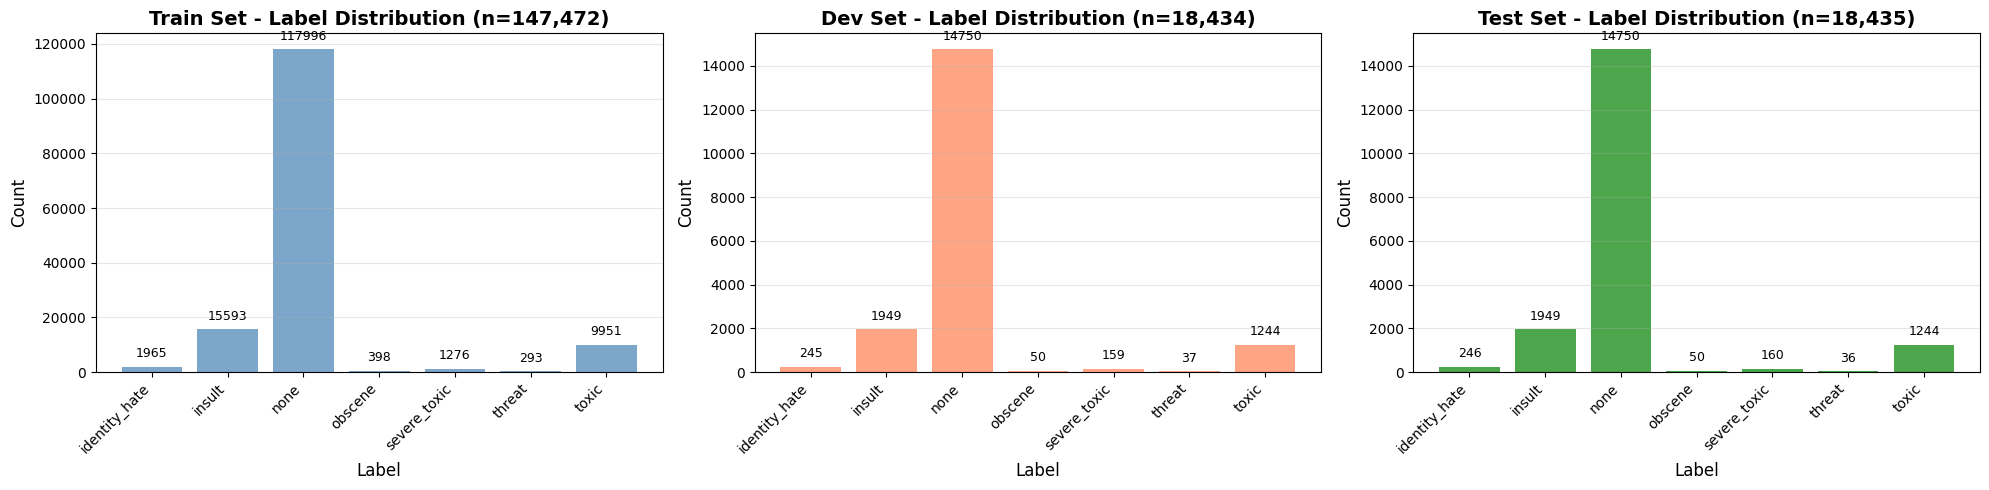


Saved: final_report_outputs/dataset_splits.png


In [13]:
# Visualize splits
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (df_split, name) in enumerate([(train_df, 'Train'), (dev_df, 'Dev'), (test_df, 'Test')]):
    label_counts = df_split['label'].value_counts().sort_index()
    axes[idx].bar(range(len(label_counts)), label_counts.values,
                  color=['steelblue', 'coral', 'green'][idx], alpha=0.7)
    axes[idx].set_xticks(range(len(label_counts)))
    axes[idx].set_xticklabels(label_counts.index, rotation=45, ha='right')
    axes[idx].set_title(f'{name} Set - Label Distribution (n={len(df_split):,})',
                        fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Label', fontsize=12)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)

    for i, v in enumerate(label_counts.values):
        axes[idx].text(i, v + max(label_counts.values)*0.02, str(v),
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_splits.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'dataset_splits.png')}")

In [14]:
# Save splits for later use
train_df.to_csv(os.path.join(OUTPUT_DIR, 'train_data.csv'), index=False)
dev_df.to_csv(os.path.join(OUTPUT_DIR, 'dev_data.csv'), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, 'test_data.csv'), index=False)

print(f"\nSaved split datasets to {OUTPUT_DIR}/")

# Save label mapping
with open(os.path.join(OUTPUT_DIR, 'label_mapping.json'), 'w') as f:
    json.dump({'label2id': label2id, 'id2label': id2label}, f, indent=2)

print(f"Saved label mapping to {OUTPUT_DIR}/label_mapping.json")


Saved split datasets to final_report_outputs/
Saved label mapping to final_report_outputs/label_mapping.json


In [15]:
# %%
print("\n" + "=" * 80)
print("TF-IDF VECTORIZATION")
print("=" * 80)

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_features=50000,
    max_df=0.8
)

# Fit on training data and transform all splits
print("Fitting TF-IDF vectorizer on training data...")
X_train_tfidf = vectorizer.fit_transform(train_df['text_clean'])
X_dev_tfidf = vectorizer.transform(dev_df['text_clean'])
X_test_tfidf = vectorizer.transform(test_df['text_clean'])

y_train = train_df['label'].values
y_dev = dev_df['label'].values
y_test = test_df['label'].values

print(f"\nTF-IDF feature shape:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Dev:   {X_dev_tfidf.shape}")
print(f"  Test:  {X_test_tfidf.shape}")
print(f"\nVocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Feature sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")

# Save vectorizer
pickle.dump(vectorizer, open(os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl'), 'wb'))
print(f"\nSaved vectorizer to {OUTPUT_DIR}/tfidf_vectorizer.pkl")


TF-IDF VECTORIZATION
Fitting TF-IDF vectorizer on training data...

TF-IDF feature shape:
  Train: (147472, 50000)
  Dev:   (18434, 50000)
  Test:  (18435, 50000)

Vocabulary size: 50,000
Feature sparsity: 99.87%

Saved vectorizer to final_report_outputs/tfidf_vectorizer.pkl


In [16]:
def evaluate_classifier(y_true, y_pred, model_name, split_name, save_cm=False):
    """
    Comprehensive evaluation of classifier performance.
    """
    print(f"\n{'='*80}")
    print(f"{model_name} - {split_name} Set Results")
    print(f"{'='*80}")

    # Overall metrics
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\nOverall Metrics:")
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Macro F1:        {macro_f1:.4f}")
    print(f"  Macro Precision: {macro_precision:.4f}")
    print(f"  Macro Recall:    {macro_recall:.4f}")
    print(f"  Weighted F1:     {weighted_f1:.4f}")

    # Per-class metrics
    print(f"\nPer-Class Metrics:")
    print(classification_report(y_true, y_pred, target_names=all_labels, digits=4, zero_division=0))

    # Confusion matrix
    if save_cm:
        cm = confusion_matrix(y_true, y_pred, labels=all_labels)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=all_labels, yticklabels=all_labels, cbar_kws={'label': 'Count'})
        plt.title(f'{model_name} - {split_name} Set\nConfusion Matrix',
                  fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.tight_layout()

        filename = f"{model_name.lower().replace(' ', '_')}_{split_name.lower()}_cm.png"
        plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches='tight')
        plt.show()
        print(f"\nSaved confusion matrix: {filename}")

    return {
        'model': model_name,
        'split': split_name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'weighted_f1': weighted_f1
    }


In [19]:
import torch
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from datasets import Dataset
import evaluate
import pandas as pd
from io import StringIO # Import StringIO from io module

# Constants
RANDOM_STATE = 42
OUTPUT_DIR = "./outputs"  # Directory to save models and confusion matrices
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fixed hyperparameters (chosen as defaults; adjust as needed)
LEARNING_RATE = 2e-5
BATCH_SIZE = 16
MAX_LENGTH = 256
NUM_LABELS = len(all_labels)  # Adjust based on your dataset (e.g., 2 for binary)

# Models
models = {
    "bert-base": "bert-base-uncased",
    "roberta": "roberta-base",
    "distilbert": "distilbert-base-uncased"
}

# Metric for Trainer
metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

# Evaluation function (similar to sklearn code's evaluate_classifier)
def evaluate_classifier(y_true, y_pred, model_name, split_name, save_cm=False):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    macro_f1 = precision_recall_fscore_support(y_true, y_pred, average='macro')[2]  # Macro F1

    print(f"{model_name} - {split_name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}")

    if save_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_LABELS), yticklabels=range(NUM_LABELS))
        plt.title(f'{model_name} - {split_name} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.savefig(os.path.join(OUTPUT_DIR, f'{model_name.lower().replace("-", "_")}_{split_name.lower()}_cm.png'))
        plt.close()
        print(f"  Saved confusion matrix to {OUTPUT_DIR}/{model_name.lower().replace('-', '_')}_{split_name.lower()}_cm.png")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1
    }

# Step 1: Load and Prepare Data (updated for train/dev/test splits)
sample_data_csv = """text_clean,label,source,label_id,text_length,word_count
i thought magneto did loose his powers because he tried to move the metal chess piece but couldn't so he was forced to move a shaky hand forward and move it gasp by hand sorry if this was already mentioned,none,jigsaw,2,205,40
asayiş hello i see you've edited asayiş to include information about syria do you have any sources for the way asayiş is suppose to be spelled and for the claim that asayiş is active in syrian kuridstan,none,jigsaw,2,202,37
please stop disrupting wikipedia to make a wp point this sort of comment is a personal attack,none,jigsaw,2,93,17
hi i let me express my strong reservations with promoting kinfra through wikipedia because it is a business entity also website of an organization is transient in nature it can be updated and may change tomorrow so as far as possible we should use only published reports that cannot change with time ii still what user suggests could be accepted as a consensus for now iii this link to public relations department does not have any word about thiruvananthapuram being a hub now it speaks about cinema related activity in thiruvananthapuram in 1970s 1980s this cannot be used to claim thiruvanantham's relevance today but it could be a citation for the statement on thiruvanthapuram being a base of malayalam cinema in the past iv corporation of thiruvanthapuram is a regional body and is not an unbiased source this website of corporation of cochin kochi also has such claims about cinema claims of these bodies about pan-kerala matters like cinema industry cannot be used a a reliable source these are outside the limits of their powers,none,jigsaw,2,1041,175"""

df = pd.read_csv(StringIO(sample_data_csv))
dataset = Dataset.from_pandas(df)

# Create train/dev/test splits (60/20/20 for demo; adjust for real data)
train_test_split = dataset.train_test_split(test_size=0.4, seed=RANDOM_STATE)
train_dataset = train_test_split["train"]
remaining = train_test_split["test"]
dev_test_split = remaining.train_test_split(test_size=0.5, seed=RANDOM_STATE)
dev_dataset = dev_test_split["train"]
test_dataset = dev_test_split["test"]

# Tokenization function
def tokenize_function(examples, tokenizer, max_len):
    return tokenizer(examples["text_clean"], truncation=True, padding="max_length", max_length=max_len)

def prepare_dataset(model_name, max_len):
    tokenizer = AutoTokenizer.from_pretrained(models[model_name])
    tokenized_train = train_dataset.map(lambda x: tokenize_function(x, tokenizer, max_len), batched=True)
    tokenized_dev = dev_dataset.map(lambda x: tokenize_function(x, tokenizer, max_len), batched=True)
    tokenized_test = test_dataset.map(lambda x: tokenize_function(x, tokenizer, max_len), batched=True)

    # Explicitly rename 'label_id' to 'labels' before setting format
    tokenized_train = tokenized_train.rename_column("label_id", "labels")
    tokenized_dev = tokenized_dev.rename_column("label_id", "labels")
    tokenized_test = tokenized_test.rename_column("label_id", "labels")

    # Set format for PyTorch, now with the correct column name
    tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    tokenized_dev.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return tokenized_train, tokenized_dev, tokenized_test, tokenizer

# Step 2: Train and Evaluate Each Model
for model_name in models:
    print("\n" + "=" * 80)
    print(f"TRAINING {model_name.upper()} MODEL")
    print("=" * 80)

    # Prepare dataset and model
    tokenized_train, tokenized_dev, tokenized_test, tokenizer = prepare_dataset(model_name, MAX_LENGTH)
    model = AutoModelForSequenceClassification.from_pretrained(models[model_name], num_labels=NUM_LABELS)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./results/{model_name}",
        eval_strategy="epoch", # Changed from evaluation_strategy
        save_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
    )

    # Trainer with early stopping
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_dev,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print(f"Training {model_name}...")
    trainer.train()

    # Generate predictions on all splits
    print("Generating predictions...")
    train_preds = trainer.predict(tokenized_train).predictions
    dev_preds = trainer.predict(tokenized_dev).predictions
    test_preds = trainer.predict(tokenized_test).predictions

    # Convert logits to class predictions
    y_train_pred = np.argmax(train_preds, axis=1)
    y_dev_pred = np.argmax(dev_preds, axis=1)
    y_test_pred = np.argmax(test_preds, axis=1)

    # True labels
    y_train = np.array(tokenized_train["labels"])
    y_dev = np.array(tokenized_dev["labels"])
    y_test = np.array(tokenized_test["labels"])

    # Evaluate
    train_results = evaluate_classifier(y_train, y_train_pred, model_name, "Train")
    dev_results = evaluate_classifier(y_dev, y_dev_pred, model_name, "Dev", save_cm=True)
    test_results = evaluate_classifier(y_test, y_test_pred, model_name, "Test", save_cm=True)

    # Save model
    model_path = os.path.join(OUTPUT_DIR, f'{model_name.lower().replace("-", "_")}_model.pkl')
    pickle.dump(trainer.model, open(model_path, 'wb'))
    print(f"\nSaved model to {model_path}")


TRAINING BERT-BASE MODEL


Map:   0%|          | 0/147472 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [ ]:
print("\n" + "=" * 80)
print("BASELINE MODEL COMPARISON")
print("=" * 80)

# Compile results
baseline_results = pd.DataFrame([
    lr_train_results, lr_dev_results, lr_test_results,
    svm_train_results, svm_dev_results, svm_test_results
])

print("\n", baseline_results.to_string(index=False))

# Save results
baseline_results.to_csv(os.path.join(OUTPUT_DIR, 'baseline_results.csv'), index=False)
print(f"\nSaved results to {OUTPUT_DIR}/baseline_results.csv")

In [ ]:
# Visualize baseline performance comparison
metrics_to_plot = ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    # Prepare data for plotting
    lr_vals = [lr_train_results[metric], lr_dev_results[metric], lr_test_results[metric]]
    svm_vals = [svm_train_results[metric], svm_dev_results[metric], svm_test_results[metric]]

    x = np.arange(3)
    width = 0.35

    ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, svm_vals, width, label='Linear SVM', color='coral', alpha=0.8)

    ax.set_xlabel('Dataset Split', fontsize=12)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(f'{metric.replace("_", " ").title()} Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Train', 'Dev', 'Test'])
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, (lr_v, svm_v) in enumerate(zip(lr_vals, svm_vals)):
        ax.text(i - width/2, lr_v + 0.02, f'{lr_v:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + width/2, svm_v + 0.02, f'{svm_v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'baseline_performance_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_DIR}/baseline_performance_comparison.png")

In [ ]:
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS (Logistic Regression)")
print("=" * 80)

# Extract feature names
feature_names = vectorizer.get_feature_names_out()
top_n = 20

# Analyze top features for each class
feature_importance = {}

for label_idx, label_name in enumerate(all_labels):
    print(f"\n{'-'*80}")
print(f"TOP {top_n} FEATURES FOR: {label_name.upper()}")
print(f"{'-'*80}")

# Get coefficients for this class
coefficients = lr_model.coef_[label_idx]

# Get top positive features (most predictive of this class)
top_indices = np.argsort(coefficients)[-top_n:][::-1]
top_features = [(feature_names[i], coefficients[i]) for i in top_indices]

feature_importance[label_name] = top_features

print("\nMost Predictive Features:")
for rank, (feature, coef) in enumerate(top_features, 1):
    print(f"  {rank:2d}. {feature:25s}: {coef:8.4f}")

In [ ]:
with open(os.path.join(OUTPUT_DIR, 'feature_importance.json'), 'w') as f:
# Convert to serializable format
    serializable = {k: [(f, float(c)) for f, c in v] for k, v in feature_importance.items()}
    json.dump(serializable, f, indent=2)
    print(f"\nSaved feature importance to {OUTPUT_DIR}/feature_importance.json")

In [ ]:
# Check which labels exist in training data
print("Labels in training data:")
print(train_df['label'].value_counts().sort_index())
print(f"\nFeature importance available for: {list(feature_importance.keys())}")

In [ ]:
# Visualize top features for selected classes
# Only include classes that exist in the model
available_classes = [label for label in ['toxic', 'severe_toxic', 'insult', 'identity_hate']
                     if label in feature_importance]

if len(available_classes) == 0:
    print("No feature importance data available for visualization")
else:
    # Adjust subplot layout based on available classes
    n_plots = len(available_classes)
    n_rows = (n_plots + 1) // 2
    n_cols = 2 if n_plots > 1 else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, label_name in enumerate(available_classes):
        ax = axes[idx]

        # Get top 15 features
        features = [f for f, c in feature_importance[label_name][:15]]
        coefs = [c for f, c in feature_importance[label_name][:15]]

        y_pos = np.arange(len(features))
        ax.barh(y_pos, coefs, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel('Coefficient Value', fontsize=11)
        ax.set_title(f'Top Features for: {label_name.upper()}', fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        # Add value labels
        for i, v in enumerate(coefs):
            ax.text(v + 0.05, i, f'{v:.3f}', va='center', fontsize=9)

    # Hide extra subplots if any
    for idx in range(len(available_classes), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'top_features_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nSaved: {OUTPUT_DIR}/top_features_visualization.png")
    print(f"Visualized {len(available_classes)} classes: {', '.join(available_classes)}")

In [ ]:
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top_features_visualization.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUTPUT_DIR}/top_features_visualization.png")
print("\n" + "=" * 80)
print("SECTIONS 1-6 COMPLETE")
print("=" * 80)
print(f"\nAll outputs saved to: {OUTPUT_DIR}/")
print("\nNext sections will cover:")
print("  7. Hyperparameter Grid Search")
print("  8. Ablation Studies")
print("  9. Cross-Dataset Generalization")
print("  10. Transformer Models")
print("  11. LLM-Assisted Annotation")
print("  12. Error Analysis")
print("  13. Final Comparisons and Conclusions")

In [24]:
from openai import OpenAI
import pandas as pd

# Initialize the OpenAI client
# Replace 'your-api-key' with your actual OpenAI API key or set it as an environment variable
client = OpenAI(api_key='your-api-key')

prompt_template = "Analyze the following text for toxicity. Classify it as one of: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'none']. Provide a brief justification.\nText: {text_input}\nClassification:"

def get_llm_label(text, prompt_template):
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",  # Or gpt-4 for higher accuracy
            messages=[
                {"role": "system", "content": "You are a helpful assistant that classifies text toxicity."},
                {"role": "user", "content": prompt_template.format(text_input=text)}
            ],
            max_tokens=100,
            temperature=0.2  # Low for consistency
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"

# NOTE: Running this on the full df_combined might take a very long time and incur significant API costs.
# It's recommended to run it on a small sample for demonstration purposes or remove this line if not needed.
# For example, to run on the first 5 rows:
df_combined_sample = df_combined.head(5).copy()
df_combined_sample['llm_label'] = df_combined_sample['text_clean'].apply(lambda x: get_llm_label(x, prompt_template))
df_combined_sample.to_csv('labeled_dataset_sample.csv', index=False)

# If you intend to run on the full dataset, ensure you have sufficient budget and time:
# df_combined['llm_label'] = df_combined['text_clean'].apply(lambda x: get_llm_label(x, prompt_template))
# df_combined.to_csv('labeled_dataset.csv', index=False)

print("OpenAI API call structure updated. Please uncomment the line to run on a sample or the full dataset.")


OpenAI API call structure updated. Please uncomment the line to run on a sample or the full dataset.


In [25]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd

df_combined = pd.read_csv('labeled_dataset_sample.csv')

kappa = cohen_kappa_score(df_combined_sample['llm_label'], df_combined_sample['label'])
print(f"Cohen’s Kappa: {kappa}")

Cohen’s Kappa: 0.0
